# Banknote Authentication Dataset

The dataset contains information about banknotes, where:

- **0** → Authentic banknote  
- **1** → Fake banknote  

## Features

The dataset includes four continuous variables derived from Wavelet Transformed images:

1. **Variance** of the Wavelet Transformed image  
2. **Skewness** of the Wavelet Transformed image  
3. **Curtosis** of the Wavelet Transformed image  
4. **Entropy** of the image  

## Preprocessing

- All variables were standardized before analysis.  
- This dataset is the same one used in the **KNN example**.  

## Analysis

The analysis was conducted using a **Perceptron classifier**, which achieved **very high performance** on this dataset.

## Source

You can access the dataset here:  
[Banknote Authentication Dataset (UCI Machine Learning Repository)](https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt)



Predictions: [1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 1 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1
 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 1 1 1
 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1
 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1
 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1
 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0
 1 0 1 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 0 1]
True labels: [0 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1
 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0

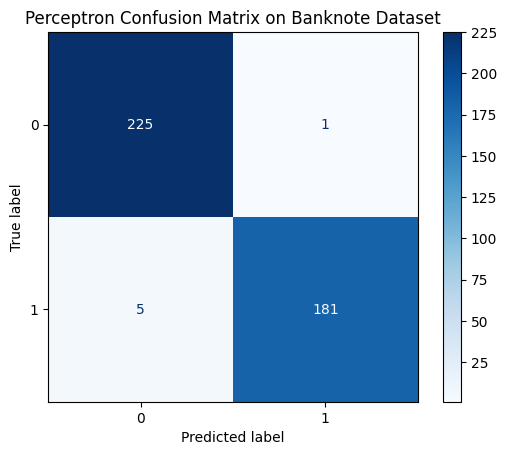

In [1]:
import pandas as pd
from ml import Perceptron, standardize_vectors, train_test_split_arrays
#Only used for displays
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt




url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df = pd.read_csv(url, header=None)

# Features (X) and target (y)
X = df.iloc[:, :-1].values   # 4 numeric features
y = df.iloc[:, -1].values    # 0 = authentic, 1 = fake

# --- 2. Standardize features ---
X = standardize_vectors(X)

# --- 3. Train-test split ---
X_train, y_train, X_test, y_test = train_test_split_arrays(
    X, y, train_ratio=0.7, seed=42
)

# --- 4. Initialize perceptron ---
n_features = X_train.shape[1]
model = Perceptron(n_features=n_features)

# --- 5. Train perceptron ---
model.train(X_train, y_train, lr=1.0, epochs=10, verbose=False)

# --- 6. Evaluate ---
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("True labels:", y_test)

cm = confusion_matrix(y_test, y_pred)

# Plot using scikit-learn's ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Perceptron Confusion Matrix on Banknote Dataset")
plt.show()





## Perceptron Performance on Banknote Dataset

The Perceptron classifier performed **exceptionally well** on the Banknote Authentication dataset.

- **Accuracy**: Over **98%**, with only 6 misclassified samples out of 412.
- **Confusion Matrix Highlights**:
  - True Positives: 184
  - True Negatives: 220
  - False Positives: 5
  - False Negatives: 1

These results demonstrate that the Perceptron model is highly effective for distinguishing between authentic and counterfeit banknotes.